In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import scipy.stats as stats
import pybedtools
from matplotlib.patches import Rectangle
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
tcga_path = 'data/tcga_mut_somaticgermline.tsv'
mutdelsnorm_path = "data/mut_deletion_lengths.tsv"
pancan_path = 'data/pancan_twohitfreq.tsv'
tumor_path = 'data/tumor_twohitfreq.tsv'
roles_path = "data/generoles.tsv"
bands_path = "data/genes_chromosome-bands_msigdb.tsv"

fragile_path = 'data/41586_2010_BFnature08768_MOESM262_ESM_Table10.tsv'
arms_path = "data/chromosome-arm-coordinates.tsv"
charm_path = "data/41586_2023_6266_MOESM8_ESM.xlsx"

In [3]:
tcga = pd.read_csv(tcga_path, sep = '\t')
mutdelsnorm = pd.read_csv(mutdelsnorm_path, sep='\t')
pancan = pd.read_csv(pancan_path, sep='\t')
tumor = pd.read_csv(tumor_path, sep='\t')
roles = pd.read_csv(roles_path, sep = '\t')
bands = pd.read_csv(bands_path, sep = '\t')

arms = pd.read_csv(arms_path, sep = '\t')
fragile = pd.read_csv(fragile_path, sep = '\t')
charm = pd.read_excel(charm_path, sheet_name = 'Table S6b', header=3)

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (12) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (21,24,26) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig 3G

Preparing datasets

In [5]:
mutdelsnorm['chrom'] = mutdelsnorm['chrom'].astype('str')
mutdelsnorm = mutdelsnorm[~mutdelsnorm['chrom'].isin(['X','Y'])] # removing sex chromosomes
print(len(mutdelsnorm))

tcgazf = tcga[(tcga['Variant_Classification']!='Silent')&(tcga['midan_filter']=='keep')].copy()
mutdelsnorm_nosil = mutdelsnorm[mutdelsnorm['Variant_Classification']!='Silent'].copy()

zf = tcgazf[['Hugo_Symbol','tissue','Chromosome','Start_Position','End_Position','Variant_Type']].rename(columns={'Chromosome':'chrom'})
zf['zf'] = 'keep'

mutdelsnorm_zf = pd.merge(mutdelsnorm_nosil,zf,on=['Hugo_Symbol','tissue','chrom','Start_Position','End_Position','Variant_Type'],how='left')
print(len(mutdelsnorm))
print(len(mutdelsnorm_zf))

mutdelsnorm_zf = mutdelsnorm_zf[mutdelsnorm_zf.zf=='keep']
print(len(mutdelsnorm_zf))

162440
162440
122083
73654


In [6]:
# prioritisation

tmp = mutdelsnorm[mutdelsnorm.Variant_Classification!='Silent'].copy()
print(len(tmp))
tmp = pd.merge(tmp,roles,on='Hugo_Symbol',how='left')
print(len(tmp))
tmp2 = tmp[tmp.role.isna().values==False]
print(len(tmp2))

tmp3 = tmp2.groupby(['tissue','chrom','del_start','del_end','del_length_normalised']).role.value_counts().to_frame().rename(columns={'role':'counts'}).reset_index().pivot(index=['tissue','chrom','del_start','del_end','del_length_normalised'],columns='role',values='counts').fillna(0).reset_index()
print(len(tmp3)) 

# taking deletions which cover mutated tsgs
tmp4 = tmp3[tmp3.TSG!=0]
# taking deletions which cover mutated tsgs only
mut_del_tsgonly = tmp4[(tmp4.ONG==0)&(tmp4.ambiguous==0)&(tmp4.essential==0)]
print(len(mut_del_tsgonly)) # unique deletions deleting only mutated tsgs

# taking deletions which cover mutated other genes
tmp4 = tmp3[(tmp3.other!=0)|(tmp3.nonessential!=0)]
# taking deletions which cover mutated other genes only
mut_del_otheronly = tmp4[(tmp4.ONG==0)&(tmp4.ambiguous==0)&(tmp4.essential==0)&(tmp4.TSG==0)]
print(len(mut_del_otheronly)) # unique deletions deleting only mutated tsgs

tsgs = roles[roles['role']=='TSG'].Hugo_Symbol.unique()
others = roles[roles['role'].isin(['other','nonessential'])].Hugo_Symbol.unique()

# TSGs
# taking all deletions overlapping mutated TSGs
mutdelsnorm_zf_tsg = mutdelsnorm_zf[mutdelsnorm_zf.Hugo_Symbol.isin(tsgs)]

# Others
# taking only deletions overlapping mutated other genes but not mutated TSGs, ONGs, ambiguous or essential genes
mutdelsnorm_zf_other = pd.merge(mutdelsnorm_zf,mut_del_otheronly[['tissue','chrom','del_start','del_end']],on=['tissue','chrom','del_start','del_end'])

122083
122083
115121
51112
6082
31262


In [7]:
# taking unique deletions for each tsg
mutdelsnorm_zf_tsg = mutdelsnorm_zf[mutdelsnorm_zf.Hugo_Symbol.isin(tsgs)][['tissue','CODE','Hugo_Symbol','chrom','del_start','del_end','del_arm','del_length_normalised','deltype','del_sa_arm','del_sa_length_normalised','deltype_sa']].drop_duplicates()
print(len(mutdelsnorm_zf_tsg))

bandsmod = bands[['gene','arm']].drop_duplicates().rename(columns={'gene':'Hugo_Symbol','arm':'gene_arm'})
mutdelsnorm_zf_tsg = pd.merge(mutdelsnorm_zf_tsg,bandsmod,on='Hugo_Symbol',how='left')
print(len(mutdelsnorm_zf_tsg))

muto = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']!='both'][['tissue','CODE','Hugo_Symbol','gene_arm','del_arm','del_length_normalised','deltype']]
mutb = mutdelsnorm_zf_tsg[mutdelsnorm_zf_tsg['del_arm']=='both'][['tissue','CODE','Hugo_Symbol','gene_arm','del_sa_arm','del_sa_length_normalised','deltype_sa']].replace({'nan':np.nan}).dropna()
mutb.columns = ['tissue','CODE','Hugo_Symbol','gene_arm','del_arm','del_length_normalised','deltype']
mut = pd.concat([muto,mutb])

print(len(mut))

6631
6631
5881


In [8]:
# continued

# calculating arm and focal percentages for each tsg (pancan)

muttsgs_armpercent_genepancan = mut.groupby(['Hugo_Symbol'])['deltype'].value_counts().to_frame().rename(columns={'deltype':'counts'}).reset_index().pivot(index=['Hugo_Symbol'],columns='deltype', values='counts').reset_index().fillna(0)
muttsgs_armpercent_genepancan['tot'] = muttsgs_armpercent_genepancan['arm'] + muttsgs_armpercent_genepancan['focal']
muttsgs_armpercent_genepancan = muttsgs_armpercent_genepancan[muttsgs_armpercent_genepancan['tot']>=10]
muttsgs_armpercent_genepancan['mutarm'] = 100*muttsgs_armpercent_genepancan['arm']/muttsgs_armpercent_genepancan['tot']

# calculating arm and focal percentages for each arm tumor type

muttsgs_armpercent_tumor = mut.groupby(['CODE','del_arm'])['deltype'].value_counts().to_frame().rename(columns={'deltype':'counts'}).reset_index().pivot(index=['CODE','del_arm'],columns='deltype', values='counts').reset_index().fillna(0)
muttsgs_armpercent_tumor['tot'] = muttsgs_armpercent_tumor['arm'] + muttsgs_armpercent_tumor['focal']
muttsgs_armpercent_tumor = muttsgs_armpercent_tumor[muttsgs_armpercent_tumor['tot']>=10]
muttsgs_armpercent_tumor['mutarm'] = 100*muttsgs_armpercent_tumor['arm']/muttsgs_armpercent_tumor['tot']

# calculating arm and focal percentages for each arm for tsgs (pancan) 

muttsgs_armpercent_armpancan = mut.groupby(['del_arm'])['deltype'].value_counts().to_frame().rename(columns={'deltype':'counts'}).reset_index().pivot(index=['del_arm'],columns='deltype', values='counts').reset_index().fillna(0)
muttsgs_armpercent_armpancan['tot'] = muttsgs_armpercent_armpancan['arm'] + muttsgs_armpercent_armpancan['focal']
muttsgs_armpercent_armpancan = muttsgs_armpercent_armpancan[muttsgs_armpercent_armpancan['tot']>=10]
muttsgs_armpercent_armpancan['mutarm'] = 100*muttsgs_armpercent_armpancan['arm']/muttsgs_armpercent_armpancan['tot']

# calculating arm and focal percentages for each tsg (tumor)

muttsgs_armpercent_genetumor = mut.groupby(['CODE','Hugo_Symbol'])['deltype'].value_counts().to_frame().rename(columns={'deltype':'counts'}).reset_index().pivot(index=['CODE','Hugo_Symbol'],columns='deltype', values='counts').reset_index().fillna(0)
muttsgs_armpercent_genetumor['tot'] = muttsgs_armpercent_genetumor['arm'] + muttsgs_armpercent_genetumor['focal']
muttsgs_armpercent_genetumor = muttsgs_armpercent_genetumor[muttsgs_armpercent_genetumor['tot']>=10]
muttsgs_armpercent_genetumor['mutarm'] = 100*muttsgs_armpercent_genetumor['arm']/muttsgs_armpercent_genetumor['tot']

In [9]:
mutdelsnorm_zf_other = mutdelsnorm_zf[mutdelsnorm_zf.Hugo_Symbol.isin(others)][['tissue','CODE','Hugo_Symbol','chrom','del_start','del_end','del_arm','del_length_normalised','deltype','del_sa_arm','del_sa_length_normalised','deltype_sa']].drop_duplicates()
print(len(mutdelsnorm_zf_other))

muto = mutdelsnorm_zf_other[mutdelsnorm_zf_other['del_arm']!='both'][['tissue','CODE','Hugo_Symbol','del_arm','del_length_normalised','deltype']]
mutb = mutdelsnorm_zf_other[mutdelsnorm_zf_other['del_arm']=='both'][['tissue','CODE','Hugo_Symbol','del_sa_arm','del_sa_length_normalised','deltype_sa']].replace({'nan':np.nan}).dropna()
mutb.columns = ['tissue','CODE','Hugo_Symbol','del_arm','del_length_normalised','deltype']
mut = pd.concat([muto,mutb])
print(len(mut))

# calculating arm and focal percentages for each arm for other genes

mutothers_armpercent_armpancan = mut.groupby(['del_arm'])['deltype'].value_counts().to_frame().rename(columns={'deltype':'counts'}).reset_index().pivot(index=['del_arm'],columns='deltype', values='counts').reset_index().fillna(0)
#mutothers_armpercent_armpancan = mut.groupby(['Hugo_Symbol','del_arm'])['deltype'].value_counts().to_frame().rename(columns={'deltype':'counts'}).reset_index().pivot(index=['Hugo_Symbol','del_arm'],columns='deltype', values='counts').reset_index().fillna(0)
mutothers_armpercent_armpancan['tot'] = mutothers_armpercent_armpancan['arm'] + mutothers_armpercent_armpancan['focal']
mutothers_armpercent_armpancan = mutothers_armpercent_armpancan[mutothers_armpercent_armpancan['tot']>=10]
mutothers_armpercent_armpancan['mutarm'] = 100*mutothers_armpercent_armpancan['arm']/mutothers_armpercent_armpancan['tot']

# calculating arm and focal percentages for each arm tumor type for each arm for other genes

mutothers_armpercent_tumor = mut.groupby(['CODE','del_arm'])['deltype'].value_counts().to_frame().rename(columns={'deltype':'counts'}).reset_index().pivot(index=['CODE','del_arm'],columns='deltype', values='counts').reset_index().fillna(0)
mutothers_armpercent_tumor['tot'] = mutothers_armpercent_tumor['arm'] + mutothers_armpercent_tumor['focal']
mutothers_armpercent_tumor = mutothers_armpercent_tumor[mutothers_armpercent_tumor['tot']>=10]
mutothers_armpercent_tumor['mutarm'] = 100*mutothers_armpercent_tumor['arm']/mutothers_armpercent_tumor['tot']
print(len(mutothers_armpercent_tumor))

51006
44170
523


SignificanceResult(statistic=0.43308525078816046, pvalue=0.00028111429201310245)


Text(0, 0.5, 'Arm-length Deletions in TSG two-hits (%)')

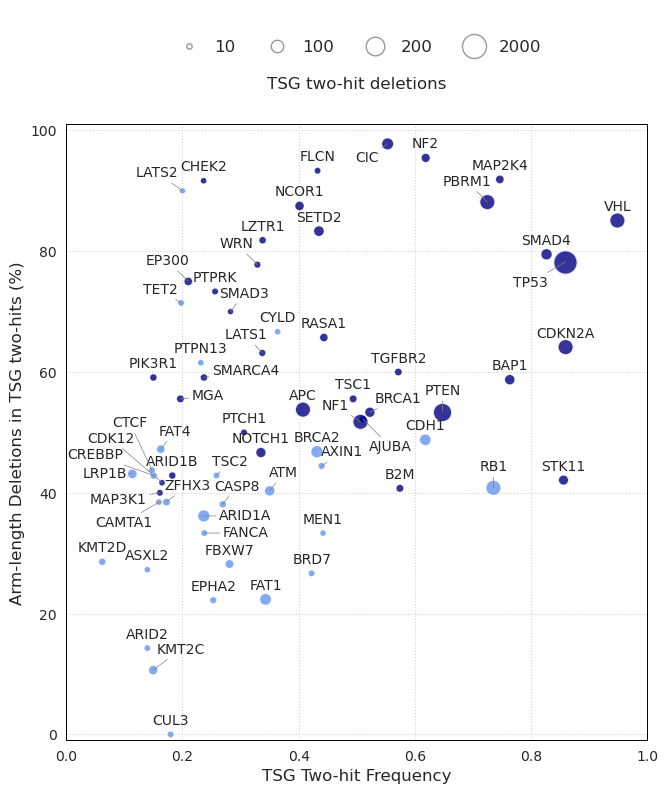

In [10]:
config_rcparams()

plt.figure(figsize=(7.5,8))
sns.set_style('whitegrid')

genes_to_annotate = {
    "PBRM1": (-15, 5),
    "TP53": (-25, -25),
    "LATS2": (-18, 3),
    "LATS1": (-12, 3),
    "RB1": (0, 5),
    "PTEN": (0, 5),
    "WRN": (-15, 5),
    "TET2": (-15, 0),
    "EP300": (-15, 5),
    "SMAD3": (10, 3),
    "ATM": (10, 3),
    "KMT2C": (20, 5),
    "BRCA1": (20, 0),
    "AJUBA": (-20, -5),
    "NF1": (-18, 2),
    "CTCF": (-16, 24),
    "CDK12": (-37, 22),
    "MAP3K1": (-30, -15),
    "CAMTA1": (-25, -25),
    "CREBBP": (-42, 5),
    "LRP1B": (-20, -10),
    "MGA": (20, -8),
    "SMARCA4": (30, -5),
    "TSC2": (10,0),
    "ARID1A": (30, -10),
    "AXIN1": (15, 0),
    "ZFHX3": (15, 2),
    "FAT4": (10, 3),
    "CASP8": (10, 3),
    "CIC": (-15, -20),
    "FANCA": (30, -10),
    "AJUBA": (20,-30)
}

data = pd.merge(pancan,muttsgs_armpercent_genepancan,on='Hugo_Symbol')
higharm = bands[bands.chr.isin(['3','5','6','8','9','10','17','18','19','14','15','22'])].gene.unique()
data['hue'] = ''
data['hue'] = data['hue'].mask(data['Hugo_Symbol'].isin(higharm),'higharm')
palette = {'':'cornflowerblue','higharm':'navy'}
x = '2hitfreq'
y = 'mutarm'

data1 = data[data['tot_y']<=100]
ax = sns.scatterplot(data=data1,x=x, y=y, hue='hue',palette=palette,alpha=0.8, size='tot_y',legend=False)

data2 = data[(data['tot_y']>100)&(data['tot_y']<=150)]
ax = sns.scatterplot(data=data2,x=x, y=y, hue='hue',palette=palette,alpha=0.8, s= 120)

data3 = data[(data['tot_y']>150)&(data['tot_y']<=200)]
ax = sns.scatterplot(data=data3,x=x, y=y, hue='hue',palette=palette,alpha=0.8, s= 180)

data4 = data[data['tot_y']>200]
ax = sns.scatterplot(data=data4,x=x, y=y, hue='hue',palette=palette,alpha=0.8, s= 300)
    

sel=data
for _, row in sel.iterrows():
    x, y = row['2hitfreq'], row['mutarm']
    label = row['Hugo_Symbol']
    dx, dy = (0, 5)  
    
    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=10,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=10,
            ha="center", va="bottom",          
        )



size_legend = [
    Line2D([], [], marker='o', color='w', label='10', 
           markerfacecolor='none',markeredgecolor='grey',alpha=0.8, markersize=np.sqrt(15)),
    Line2D([], [], marker='o', color='w', label='100', 
           markerfacecolor='none',markeredgecolor='grey',alpha=0.8, markersize=np.sqrt(80)),
    Line2D([], [], marker='o', color='w', label='200', 
           markerfacecolor='none',markeredgecolor='grey',alpha=0.8, markersize=np.sqrt(180)),
    Line2D([], [], marker='o', color='w', label='2000', 
           markerfacecolor='none',markeredgecolor='grey',alpha=0.8, markersize=np.sqrt(300)),
]

# Add legend to axis
legend = ax.legend(
    handles=size_legend,
    title='TSG two-hit deletions',
    loc='upper center',     
    bbox_to_anchor=(0.5, 1.2), 
    ncol=4,                
    fontsize=12,
    title_fontsize=12,
    frameon=False,          
    handletextpad=0.5,
    columnspacing=1.5,
)
legend.get_title().set_position((0,-60))

print(stats.spearmanr(data['2hitfreq'],data['mutarm']))

for spine in plt.gca().spines.values():
    spine.set_edgecolor('k')       

ax.grid(True,color='lightgrey', linestyle =':')
plt.xlim(0,1)
plt.ylim(-1,101)
plt.xlabel('TSG Two-hit Frequency', fontsize=12)
plt.ylabel('Arm-length Deletions in TSG two-hits (%)', fontsize=12)

# Fig 3C

In [12]:
tumor_colors = {
    'KIRC': '#9ACD32',   # yellow-green
    'BRCA': '#DEAF05',  # golden yellow
    'OV':   '#FF6F61',  # coral
    'BLCA': '#70C9D4',  # light cyan-blue
    'HNSC': '#d55e00',  # dark orange
    'LUAD': '#E3ACC5',  # soft pink
    'SKCM': '#029E43',  # emerald green
    'STAD': '#D62981',  # magenta-pink
    'LUSC': '#0173b2',  # royal blue
    'GBM':  '#8B1C62',  # deep burgundy
    'PRAD': '#8B0000',   # dark red
    'ESCA': '#FFD700',   # vivid yellow
    'COAD': '#4B0082',   # indigo
    'TGCT': '#FF4500',   # orange-red
    'SARC': '#cbf7f3',   # turquoise
    'THCA': '#6A5ACD',   # slate blue
    'UVM':  '#8FBC8F',   # dark sea green
    'CHOL': '#A52A2A',   # brown
    'GBM':  '#2c666b',   # dark turquoise
    'OV':   '#9932CC',   # dark orchid
    'UCEC': '#F08080',   # light coral
    'PAAD': '#000000',   # black
    'KIRP': '#F0E68C',   # khaki
    'LIHC': '#B22222',   # firebrick
    'THYM': '#7FFFD4',   # aquamarine
    'MESO': '#eda1ed',   # violet
    'CESC': '#5F9EA0',   # cadet blue
    'LAML': '#D2691E',   # chocolate
    'READ': '#c29457',   # light chocolate
    'LGG':  '#f7b499',   # light salmon
    'DLBC': '#2F4F4F',   # dark slate gray
    'KICH': '#FF00FF',   # magenta
    'UCS':  '#ADFF2F',   # green-yellow
    'ACC':  '#DC143C',   # crimson
    'PCPG': '#1E90FF'    # dodger blue
}

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


SignificanceResult(statistic=0.7877297802359015, pvalue=1.583602867018446e-12)


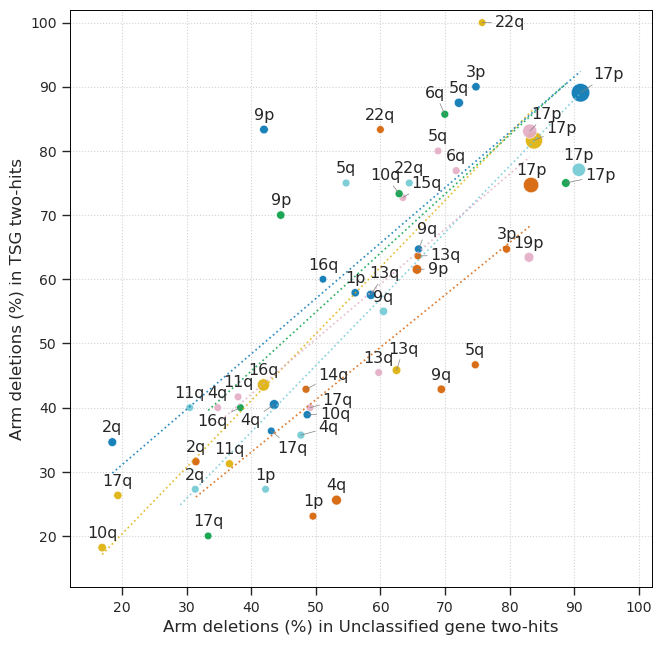

In [13]:
config_rcparams()

plt.figure(figsize=(7.5,7.5))

arms_to_annotate = {
    "17pPAAD": (5,5),
    "17pLUAD": (12,2),
    "17pSTAD": (-5,5),
    "18qPAAD": (-5,5),
    "17pBRCA": (20,-2),
    "17pLUSC": (20,3),
    "17pOV": (15,5),
    "17pSKCM": (25,-5),
    "18qSTAD": (-12,5),
    "15qLUAD": (17,0),
    "10qSKCM": (-10,3),
    "9qLUSC": (6,4),
    "1pSTAD": (15,-5),
    "16qSKCM": (-20,-20),
    "13qLUSC": (10,5),
    "6qSKCM": (-7,5),
    "17qLUSC": (15,-23),
    "17qLUAD": (20,-5),
    "4qBLCA": (20,-5),
    "4qLUSC": (-17,-22),
    "14qHNSC": (20,0),
    "22qBRCA": (20,-10),
    "9pHNSC": (15,-10),
    "13qHNSC": (20,-10),
    "13qBRCA": (5,5),
    "10qLUSC": (20,-10)
}

data = pd.merge(mutothers_armpercent_tumor,muttsgs_armpercent_tumor,on=['del_arm','CODE'])
data['del_arm'] = data['del_arm'].apply(lambda x:x[3:])
data['arm_code']=data['del_arm']+data['CODE']
data = data[data.CODE.isin(['HNSC','BLCA','BRCA','LUAD','LUSC','SKCM'])]


x = 'mutarm_x'
y = 'mutarm_y'

ax = sns.scatterplot(data=data,x=x, y=y, alpha = 0.9, size='tot_y',sizes=(30,180), hue='CODE', palette=tumor_colors, legend=False)
ax = sns.regplot(data=data[data['CODE']=='BLCA'],x=x, y=y, ci=None, scatter=False, line_kws={"linewidth":1.25,"alpha":0.8, "linestyle":':'},color='#70C9D4')
ax = sns.regplot(data=data[data['CODE']=='BRCA'],x=x, y=y, ci=None, scatter=False, line_kws={"linewidth":1.25,"alpha":0.8, "linestyle":':'},color='#DEAF05')
ax = sns.regplot(data=data[data['CODE']=='HNSC'],x=x, y=y, ci=None, scatter=False, line_kws={"linewidth":1.25,"alpha":0.8, "linestyle":':'}, color='#d55e00')
ax = sns.regplot(data=data[data['CODE']=='LUAD'],x=x, y=y, ci=None, scatter=False, line_kws={"linewidth":1.25,"alpha":0.8, "linestyle":':'},color='#E3ACC5')
ax = sns.regplot(data=data[data['CODE']=='LUSC'],x=x, y=y, ci=None, scatter=False, line_kws={"linewidth":1.25,"alpha":0.8, "linestyle":':'},color='#0173b2')
ax = sns.regplot(data=data[data['CODE']=='SKCM'],x=x, y=y, ci=None, scatter=False, line_kws={"linewidth":1.25,"alpha":0.8, "linestyle":':'},color='#029E43')

sel=data
for _, row in sel.iterrows():
    x, y = row['mutarm_x'], row['mutarm_y']
    point = row['arm_code']
    label = row['del_arm']#+'_'+row['CODE']
    dx, dy = (0, 5)  
    
    if point in arms_to_annotate:
        extra_dx, extra_dy = arms_to_annotate[point]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=11.5,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=11.5,
            ha="center", va="bottom",          
        )

#ax.plot([-10, 110], [-10, 110],linestyle='-', color="gray",linewidth=0.75)
ax.grid(True,color='lightgrey', linestyle =':')
plt.xlim(12,102)
plt.ylim(12,102)
plt.xlabel('Arm deletions (%) in Unclassified gene two-hits',fontsize=12)
plt.ylabel('Arm deletions (%) in TSG two-hits',fontsize=12)

for spine in plt.gca().spines.values():
    spine.set_edgecolor('k') 
    
# Force tick marks to be visible
ax.tick_params(
    axis='both',
    which='major',
    direction='out',
    length=6,
    width=1,
    bottom=True,
    left=True
)

# Make sure tick labels are visible
ax.xaxis.set_tick_params(labelbottom=True)
ax.yaxis.set_tick_params(labelleft=True)

print(stats.spearmanr(data['mutarm_x'].values,data['mutarm_y'].values))

---

# Fig S5C

In [14]:
# preparing dataset

tmp = ['1p', '1q', '2p', '2q','3p', '3q', '4p', '4q', '5p', '5q', '6p', '6q', '7p', '7q',
       '8p', '8q', '9p', '9q', '10p', '10q', '11p', '11q', '12p', '12q', '13q',
      '14q', '15q', '16p', '16q', '17p', '17q', '18p',
       '18q', '19p', '19q',  '20p', '20q', '21q', '22q'] # removed sex and acrocentric chromosomes
armorder = pd.DataFrame({'arm':tmp}).set_index('arm')

# armlengths from msigdb

armlengths = arms[['arm','arm_length']].copy()
armlengths['arm'] = armlengths['arm'].apply(lambda x:x[3:])
armlengths = armorder.join(armlengths.set_index('arm'))

# coefficients from rameen's paper

charm_mod = charm[charm['direction']=='del'].copy()
charm_mod['arm'] = charm_mod['arm'].astype('str').replace({'13':'13q','14':'14q','15':'15q','21':'21q','22':'22q'})
ess_charm = armorder.join(charm_mod[['arm','CharmEssential_coefficient']].set_index('arm'))
og_charm = armorder.join(charm_mod[['arm','CharmOG_coefficient']].set_index('arm'))
comb_charm = armorder.join(charm_mod[['arm','Charm(TSG-OG-Ess)coefficient']].set_index('arm'))
rfnet = armorder.join(charm_mod[['arm','relative_fitness_net']].set_index('arm'))

# fragile site density

tmp = fragile[fragile['Type']=='Common'][['Chr','Start','End']]
fragile_bd = pybedtools.BedTool.from_dataframe(tmp)

print(len(fragile_bd))
fragile_bd = fragile_bd.sort().merge()
print(len(fragile_bd))
    
armcoords_bd = pybedtools.BedTool.from_dataframe(arms[['chr','arm_start','arm_end','arm']])
armcoords_fragile_bd = armcoords_bd.intersect(fragile_bd, wao=True)
armcoords_fragile = pybedtools.BedTool.to_dataframe(armcoords_fragile_bd)
armcoords_fragile.columns = ['chr','arm_start','arm_end','arm','tmp','fra_start','fra_end','overlap']

fragile_density = armcoords_fragile.groupby('arm')['overlap'].sum().to_frame().rename(columns={'overlap':'fra_overlap'}).reset_index()
fragile_density['arm'] = fragile_density['arm'].apply(lambda x:x[3:])
fragile_density = armorder.join(fragile_density.set_index('arm'))
fragile_density = fragile_density.join(armlengths.rename(columns={'arm_length2':'arm_length'}))
fragile_density['fra_density'] = 100*fragile_density['fra_overlap']/fragile_density['arm_length']
fragile_density = fragile_density[['fra_density']]

# number of genes

genenumbers = bands.groupby('arm')['gene'].nunique().to_frame().rename(columns={'gene':'gene_number'}).reset_index()
genenumbers['arm'] = genenumbers['arm'].apply(lambda x:x[3:])
genenumbers = armorder.join(genenumbers.set_index('arm'))
genenumbers.gene_number.sum()  # this includes all genes in the bands dataset

# combining all
arm_features = armlengths.join(fragile_density).join(og_charm).join(ess_charm).join(comb_charm).join(genenumbers).join(rfnet).reset_index()


muttsgs_armpercent_armpancan['del_arm'] = muttsgs_armpercent_armpancan['del_arm'].apply(lambda x:x[3:])
mutothers_armpercent_armpancan['del_arm'] = mutothers_armpercent_armpancan['del_arm'].apply(lambda x:x[3:])
arm_features['del_arm'] = arm_features['arm'].copy()
data1 = pd.merge(arm_features,muttsgs_armpercent_armpancan,on='del_arm')
data2 = pd.merge(arm_features,mutothers_armpercent_armpancan,on='del_arm')

muttsgs_armpercent_tumor['arm'] = muttsgs_armpercent_tumor['del_arm'].apply(lambda x:x[3:])
mutothers_armpercent_tumor['arm'] = mutothers_armpercent_tumor['del_arm'].apply(lambda x:x[3:])
data3 = pd.merge(arm_features,muttsgs_armpercent_tumor,on='arm')
data4 = pd.merge(arm_features,mutothers_armpercent_tumor,on='arm')

94
91


PearsonRResult(statistic=-0.556901489787729, pvalue=0.002083115887194695)
PearsonRResult(statistic=-0.510171708406817, pvalue=0.0009068404210500036)
SignificanceResult(statistic=-0.5763546798029557, pvalue=0.0013272684411269582)
SignificanceResult(statistic=-0.5097165991902833, pvalue=0.0009181211563501372)


Text(0.5, 0, 'Arm Length (bp)')

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


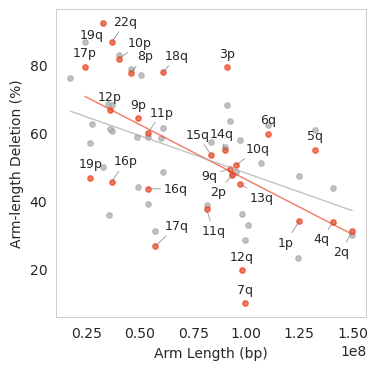

In [15]:
config_rcparams()

plt.figure(figsize=(4,4))

arms_to_annotate = {
    "19q": (-8,-18),
    "22q": (10,5),
    "11p": (10,5),
    "13q": (5,5),
    "2p": (-10,-22),
    "10p": (15,2),
    "8p": (10,2),
    "18q": (10,2),
    "10q": (15,2),
    "14q": (-2,2),
    "15q": (-10,5),
    "9q": (-15,-15),
    "13q": (15,-20),
    "4q": (-8,-22),
    "1p": (-10,-25),
    "2q": (-8,-25),
    "11q": (5,-25),
    "16q": (20,-10),
    "17q": (15,5),
    "16p": (10,5),
    
}

ax = sns.regplot(data=data1,x='arm_length',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":1}, line_kws={"linewidth":1,"alpha":0.7},color='#F0401D') 
ax = sns.regplot(data=data2,x='arm_length',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":0}, line_kws={"linewidth":1,"alpha":0.7},color='darkgrey') 

print(stats.pearsonr(data1['arm_length'].values,data1['mutarm'].values))
print(stats.pearsonr(data2['arm_length'].values,data2['mutarm'].values))
print(stats.spearmanr(data1['arm_length'].values,data1['mutarm'].values))
print(stats.spearmanr(data2['arm_length'].values,data2['mutarm'].values))

sel=data1
for _, row in sel.iterrows():
    x, y = row['arm_length'], row['mutarm']
    label = row['del_arm']
    dx, dy = (0, 5)  
    
    if label in arms_to_annotate:
        extra_dx, extra_dy = arms_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=9,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=9,
            ha="center", va="bottom",          
        )


ax.grid(False)

plt.ylabel('Arm-length Deletion (%)')
plt.xlabel('Arm Length (bp)')

PearsonRResult(statistic=-0.22625694095243687, pvalue=0.24696825481519152)
PearsonRResult(statistic=-0.3467560996920596, pvalue=0.030569315826458093)
SignificanceResult(statistic=-0.3016671806994735, pvalue=0.1187377210147151)
SignificanceResult(statistic=-0.4118203143703185, pvalue=0.009190950501977326)


Text(0.5, 0, 'Fragile site coverage')

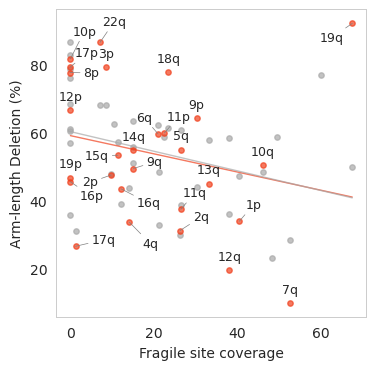

In [16]:
config_rcparams()

plt.figure(figsize=(4,4))

arms_to_annotate = {
    "2q": (15,0),
    "11q": (10,2),
    "1p": (10,2),
    "11p": (10,2),
    "9q": (15,-5),
    "6q": (-10,2),
    "2p": (-15,-15),
    "15q": (-15,-10),
    "16p": (15,-20),
    "17q": (20,-5),
    "16q": (20,-20),
    "4q": (15,-25),
    "17p": (12,0),
    "10p": (10,10),
    "8p": (15,-10),
    "22q": (10,5),
    "19q": (-15,-20),
}

ax = sns.regplot(data=data1,x='fra_density',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":1}, line_kws={"linewidth":1,"alpha":0.7},color='#F0401D') 
ax = sns.regplot(data=data2,x='fra_density',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":0}, line_kws={"linewidth":1,"alpha":0.7},color='darkgrey') 

print(stats.pearsonr(data1['fra_density'].values,data1['mutarm'].values))
print(stats.pearsonr(data2['fra_density'].values,data2['mutarm'].values))
print(stats.spearmanr(data1['fra_density'].values,data1['mutarm'].values))
print(stats.spearmanr(data2['fra_density'].values,data2['mutarm'].values))

sel=data1
for _, row in sel.iterrows():
    x, y = row['fra_density'], row['mutarm']
    label = row['del_arm']
    dx, dy = (0, 5)  
    
    if label in arms_to_annotate:
        extra_dx, extra_dy = arms_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=9,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=9,
            ha="center", va="bottom",          
        )

ax.grid(False)

plt.ylabel('Arm-length Deletion (%)')
plt.xlabel('Fragile site coverage')

PearsonRResult(statistic=-0.36738158776852475, pvalue=0.05445046870513501)
PearsonRResult(statistic=-0.15647233741842972, pvalue=0.3414756647859804)
SignificanceResult(statistic=-0.46798029556650245, pvalue=0.012026034443145883)
SignificanceResult(statistic=-0.20689306165470991, pvalue=0.20632505676635174)


Text(0.5, 0, 'Oncogenes CHARM score')

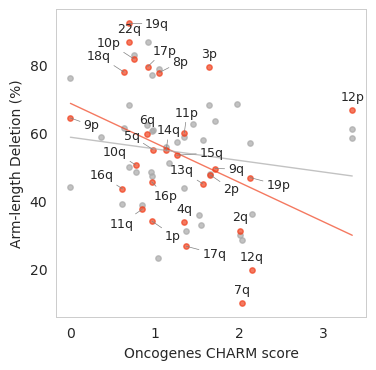

In [17]:
config_rcparams()

data=plt.figure(figsize=(4,4))

arms_to_annotate = {
    "17q": (20,-15),
    "19p": (20,-15),
    "9p": (15,-15),
    "19q": (20,-10),
    "16p": (10,-20),
    "1p": (15,-20),
    "11q": (-15,-20),
    "13q": (-15,0),
    "16q": (-15,0),
    "10q": (-15,0),
    "18q": (-18,2),
    "10p": (-18,2),
    "8p": (15,-2),
    "17p": (12,2),
    "15q": (25,-8),
    "9q": (15,-10),
    "2p": (15,-20),
    "5q": (-15,0),
    "11p": (2,5),
    "14q": (2,5),
}

ax = sns.regplot(data=data1,x='CharmOG_coefficient',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":1}, line_kws={"linewidth":1,"alpha":0.7},color='#F0401D') 
ax = sns.regplot(data=data2,x='CharmOG_coefficient',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":0}, line_kws={"linewidth":1,"alpha":0.7},color='darkgrey') 

print(stats.pearsonr(data1['CharmOG_coefficient'].values,data1['mutarm'].values))
print(stats.pearsonr(data2['CharmOG_coefficient'].values,data2['mutarm'].values))
print(stats.spearmanr(data1['CharmOG_coefficient'].values,data1['mutarm'].values))
print(stats.spearmanr(data2['CharmOG_coefficient'].values,data2['mutarm'].values))

sel=data1
for _, row in sel.iterrows():
    x, y = row['CharmOG_coefficient'], row['mutarm']
    label = row['del_arm']
    dx, dy = (0, 5)  
    
    if label in arms_to_annotate:
        extra_dx, extra_dy = arms_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=9,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=9,
            ha="center", va="bottom",          
        )


ax.grid(False)

plt.ylabel('Arm-length Deletion (%)')
plt.xlabel('Oncogenes CHARM score')

PearsonRResult(statistic=-0.3136971961694345, pvalue=0.10403827864512918)
PearsonRResult(statistic=-0.31494033849992253, pvalue=0.05084017100215744)
SignificanceResult(statistic=-0.3169129720853858, pvalue=0.10034996385520087)
SignificanceResult(statistic=-0.34554655870445344, pvalue=0.03119409406156641)


Text(0.5, 0, 'Essential genes CHARM score')

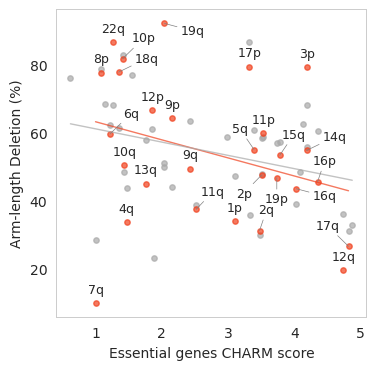

In [18]:
config_rcparams()

plt.figure(figsize=(4,4))

arms_to_annotate = {
    "2q": (5,5),
    "11q": (12,3),
    "17q": (-15,5),
    "16q": (20,-15),
    "19p": (0,-25),
    "6q": (15,5),
    "18q": (20,0),
    "19q": (20,-15),
    "10p": (15,5),
    "16p": (5,5),
    "14q": (20,0),
    "2p": (-13,-23),
    "5q": (-10,5),
    "15q": (10,5),
}

ax = sns.regplot(data=data1,x='CharmEssential_coefficient',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":1}, line_kws={"linewidth":1,"alpha":0.7},color='#F0401D') 
ax = sns.regplot(data=data2,x='CharmEssential_coefficient',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":0}, line_kws={"linewidth":1,"alpha":0.7},color='darkgrey') 

print(stats.pearsonr(data1['CharmEssential_coefficient'].values,data1['mutarm'].values))
print(stats.pearsonr(data2['CharmEssential_coefficient'].values,data2['mutarm'].values))
print(stats.spearmanr(data1['CharmEssential_coefficient'].values,data1['mutarm'].values))
print(stats.spearmanr(data2['CharmEssential_coefficient'].values,data2['mutarm'].values))

sel=data1
for _, row in sel.iterrows():
    x, y = row['CharmEssential_coefficient'], row['mutarm']
    label = row['del_arm']
    dx, dy = (0, 5)  
    
    if label in arms_to_annotate:
        extra_dx, extra_dy = arms_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=9,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=9,
            ha="center", va="bottom",          
        )


ax.grid(False)

plt.ylabel('Arm-length Deletion (%)')
plt.xlabel('Essential genes CHARM score')

PearsonRResult(statistic=0.4631948425415421, pvalue=0.013053812685016793)
PearsonRResult(statistic=0.34815892668570203, pvalue=0.02985763744698672)
SignificanceResult(statistic=0.4477285166940339, pvalue=0.0168874666584397)
SignificanceResult(statistic=0.3242914979757085, pvalue=0.043998349104390405)


Text(0.5, 0, 'TSG-OG-Ess CHARM score')

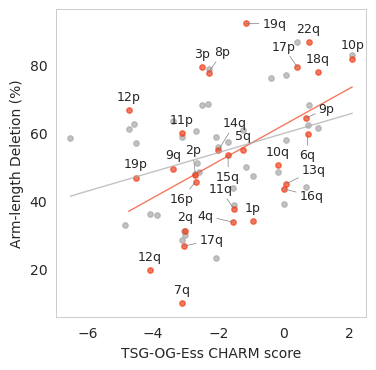

In [19]:
config_rcparams()

plt.figure(figsize=(4,4))

arms_to_annotate = {
    "17q": (20,-5),
    "4q": (-20,-5),
    "11q": (-10,5),
    "17p": (-10,5),
    "8p": (10,5),
    "19q": (20,-10),
    "13q": (20,0),
    "16q": (20,-15),
    "15q": (0,-25),
    "14q": (12,10),
    "9p": (15,-3),
    "6q": (0,-25),
    "16p": (-10,-22),
    "2p": (-2,8),
}

ax = sns.regplot(data=data1,x='Charm(TSG-OG-Ess)coefficient',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":1}, line_kws={"linewidth":1,"alpha":0.7},color='#F0401D') 
ax = sns.regplot(data=data2,x='Charm(TSG-OG-Ess)coefficient',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":0}, line_kws={"linewidth":1,"alpha":0.7},color='darkgrey') 

print(stats.pearsonr(data1['Charm(TSG-OG-Ess)coefficient'].values,data1['mutarm'].values))
print(stats.pearsonr(data2['Charm(TSG-OG-Ess)coefficient'].values,data2['mutarm'].values))
print(stats.spearmanr(data1['Charm(TSG-OG-Ess)coefficient'].values,data1['mutarm'].values))
print(stats.spearmanr(data2['Charm(TSG-OG-Ess)coefficient'].values,data2['mutarm'].values))

sel=data1
for _, row in sel.iterrows():
    x, y = row['Charm(TSG-OG-Ess)coefficient'], row['mutarm']
    label = row['del_arm']
    dx, dy = (0, 5)  
    
    if label in arms_to_annotate:
        extra_dx, extra_dy = arms_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=9,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=9,
            ha="center", va="bottom",          
        )


ax.grid(False)

plt.ylabel('Arm-length Deletion (%)')
plt.xlabel('TSG-OG-Ess CHARM score')

PearsonRResult(statistic=0.41035196559558995, pvalue=0.030087823809633412)
PearsonRResult(statistic=0.4485371395282214, pvalue=0.004185023136653977)
SignificanceResult(statistic=0.40831964969896006, pvalue=0.030994624861858097)
SignificanceResult(statistic=0.4681411008576484, pvalue=0.00265183233434825)


Text(0.5, 0, 'Relative Fitness (CNA)')

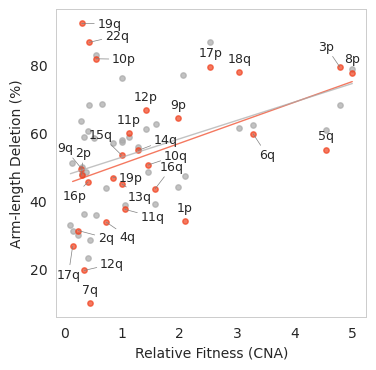

In [20]:
config_rcparams()

plt.figure(figsize=(4,4))

arms_to_annotate = {
    "12q": (20,-5),
    "16q": (12,6),
    "17q": (-3,-30),
    "2q": (20,-15),
    "11q": (20,-15),
    "19q": (20,-10),
    "22q": (20,-5),
    "10p": (20,-10),
    "3p": (-10,5),
    "6q": (10,-25),
    "4q": (15,-20),
    "13q": (13,-19),
    "19p": (13,-10),
    "16p": (-10,-20),
    "10q": (20,-3),
    "14q": (20,-2),
    "15q": (-15,5),
    "9q": (-12,5),
    "2p": (1,6),

}

ax = sns.regplot(data=data1,x='relative_fitness_net',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":1}, line_kws={"linewidth":1,"alpha":0.7},color='#F0401D') 
ax = sns.regplot(data=data2,x='relative_fitness_net',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":0}, line_kws={"linewidth":1,"alpha":0.7},color='darkgrey') 

print(stats.pearsonr(data1['relative_fitness_net'].values,data1['mutarm'].values))
print(stats.pearsonr(data2['relative_fitness_net'].values,data2['mutarm'].values))
print(stats.spearmanr(data1['relative_fitness_net'].values,data1['mutarm'].values))
print(stats.spearmanr(data2['relative_fitness_net'].values,data2['mutarm'].values))

sel=data1
for _, row in sel.iterrows():
    x, y = row['relative_fitness_net'], row['mutarm']
    label = row['del_arm']
    dx, dy = (0, 5)  
    
    if label in arms_to_annotate:
        extra_dx, extra_dy = arms_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=9,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=9,
            ha="center", va="bottom",          
        )


ax.grid(False)

plt.ylabel('Arm-length Deletion (%)')
plt.xlabel('Relative Fitness (CNA)')

PearsonRResult(statistic=-0.5885108490752206, pvalue=0.0009871206448299414)
PearsonRResult(statistic=-0.6026671471442413, pvalue=4.9091191733574304e-05)
SignificanceResult(statistic=-0.5934035911598666, pvalue=0.0008733307794040405)
SignificanceResult(statistic=-0.6295865183426104, pvalue=1.7553712527551287e-05)


Text(0.5, 0, 'Total genes')

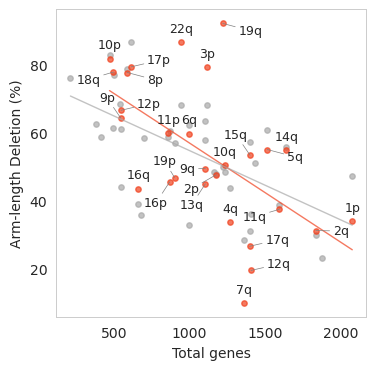

In [21]:
config_rcparams()

plt.figure(figsize=(4,4))

arms_to_annotate = {
    "12q": (20,-5),
    "19q": (20,-15),
    "5q": (20,-15),
    "17q": (20,-5),
    "16p": (-10,-25),
    "13q": (-10,-25),
    "17p": (20,-5),
    "8p": (20,-15),
    "18q": (-18,-15),
    "9q": (-13,-10),
    "2p": (-18,-20),
    "11q": (-18,-15),
    "15q": (-10,5),
    "9p": (-10,5),
    "2q": (18,-10),
    "12p": (20,-5),
    "19p": (-7,2),
}

ax = sns.regplot(data=data1,x='gene_number',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":1}, line_kws={"linewidth":1,"alpha":0.7},color='#F0401D') 
ax = sns.regplot(data=data2,x='gene_number',y='mutarm',ci=None,scatter_kws={"s":15,"alpha":0.7,"zorder":0}, line_kws={"linewidth":1,"alpha":0.7},color='darkgrey') 

print(stats.pearsonr(data1['gene_number'].values,data1['mutarm'].values))
print(stats.pearsonr(data2['gene_number'].values,data2['mutarm'].values))
print(stats.spearmanr(data1['gene_number'].values,data1['mutarm'].values))
print(stats.spearmanr(data2['gene_number'].values,data2['mutarm'].values))

sel=data1
for _, row in sel.iterrows():
    x, y = row['gene_number'], row['mutarm']
    label = row['del_arm']
    dx, dy = (0, 5)  
    
    if label in arms_to_annotate:
        extra_dx, extra_dy = arms_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=9,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=9,
            ha="center", va="bottom",          
        )


ax.grid(False)

plt.ylabel('Arm-length Deletion (%)')
plt.xlabel('Total genes')

---

# Fig 3D

In [22]:
tsgarm = stats.spearmanr(data1['arm_length'],data1['mutarm'])
tsggene = stats.spearmanr(data1['gene_number'],data1['mutarm'])
tsgfra = stats.spearmanr(data1['fra_density'],data1['mutarm'])
tsgog = stats.spearmanr(data1['CharmOG_coefficient'],data1['mutarm'])
tsgess = stats.spearmanr(data1['CharmEssential_coefficient'],data1['mutarm'])
tsgcomb = stats.spearmanr(data1['Charm(TSG-OG-Ess)coefficient'],data1['mutarm'])
tsgrfnet = stats.spearmanr(data1['relative_fitness_net'],data1['mutarm'])

otharm = stats.spearmanr(data2['arm_length'],data2['mutarm'])
othgene = stats.spearmanr(data2['gene_number'],data2['mutarm'])
othfra = stats.spearmanr(data2['fra_density'],data2['mutarm'])
othog = stats.spearmanr(data2['CharmOG_coefficient'],data2['mutarm'])
othess = stats.spearmanr(data2['CharmEssential_coefficient'],data2['mutarm'])
othcomb = stats.spearmanr(data2['Charm(TSG-OG-Ess)coefficient'],data2['mutarm'])
othrfnet = stats.spearmanr(data2['relative_fitness_net'],data2['mutarm'])

x = pd.DataFrame({'Gene':'TSG','Arm length':tsgarm,'Total genes':tsggene,'Fragile site \ncoverage':tsgfra,'Oncogenes \nCHARM score':tsgog, 'Essential genes \nCHARM score':tsgess,'TSG-OG-Ess \nCHARM score':tsgcomb,'Relative Fitness \n(CNA)':tsgrfnet})
y = pd.DataFrame({'Gene':'Other genes','Arm length':otharm,'Total genes':othgene,'Fragile site \ncoverage':othfra,'Oncogenes \nCHARM score':othog, 'Essential genes \nCHARM score':othess,'TSG-OG-Ess \nCHARM score':othcomb,'Relative Fitness \n(CNA)':othrfnet})
corrs = pd.concat([x,y]).set_index('Gene').iloc[[0,2]]
pvals = pd.concat([x,y]).set_index('Gene').iloc[[1,3]]

In [23]:
# checking how many tumor types it is significant in

def sigtumor(col,data):
    
    c = []
    r = []
    p = []
    tot = 0

    for i in data.CODE.unique():
        subdf = data[data.CODE==i]
        if len(subdf)>=5:
            tot += 1
            test = stats.spearmanr(subdf[str(col)],subdf['mutarm'])
            if round(test[1],2) <= 0.05:
                c.append(i)
                r.append(test[0])
                p.append(test[1])    

    annot = str(len(c))+'/'+str(tot)
    return(annot,c,r,p)

In [24]:
annotations = corrs.copy()
annotations.iloc[0,0] = 'ρ = -0.58\np ≤ 0.001\n'+sigtumor('arm_length',data3)[0]
annotations.iloc[0,1] = 'ρ = -0.59\np ≤ 0.001\n'+sigtumor('gene_number',data3)[0]
annotations.iloc[0,2] = 'ρ = -0.30\np ≤ 0.1\n'+sigtumor('fra_density',data3)[0]
annotations.iloc[0,3] = 'ρ = -0.47\np ≤ 0.01\n'+sigtumor('CharmOG_coefficient',data3)[0]
annotations.iloc[0,4] = 'ρ = -0.32\np ≤ 0.1\n'+sigtumor('CharmEssential_coefficient',data3)[0]
annotations.iloc[0,5] = 'ρ = 0.45\np ≤ 0.05\n'+sigtumor('Charm(TSG-OG-Ess)coefficient',data3)[0]
annotations.iloc[0,6] = 'ρ = 0.41\np ≤ 0.05\n'+sigtumor('relative_fitness_net',data3)[0]

annotations.iloc[1,0] = 'ρ = -0.51\np ≤ 0.001\n'+sigtumor('arm_length',data4)[0]
annotations.iloc[1,1] = 'ρ = -0.63\np ≤ 0.001\n'+sigtumor('gene_number',data4)[0]
annotations.iloc[1,2] = 'ρ = -0.41\np ≤ 0.01\n'+sigtumor('fra_density',data4)[0]
annotations.iloc[1,3] = 'ρ = -0.21\np ≤ 0.2\n'+sigtumor('CharmOG_coefficient',data4)[0]
annotations.iloc[1,4] = 'ρ = -0.35\np ≤ 0.05\n'+sigtumor('CharmEssential_coefficient',data4)[0]
annotations.iloc[1,5] = 'ρ = 0.32\np ≤ 0.05\n'+sigtumor('Charm(TSG-OG-Ess)coefficient',data4)[0]
annotations.iloc[1,6] = 'ρ = 0.47\np ≤ 0.01\n'+sigtumor('relative_fitness_net',data4)[0]
annotations

,Arm length,Total genes,Fragile site \ncoverage,Oncogenes \nCHARM score,Essential genes \nCHARM score,TSG-OG-Ess \nCHARM score,Relative Fitness \n(CNA)
Gene,,,,,,,
TSG,ρ = -0.58\np ≤ 0.001\n3/8,ρ = -0.59\np ≤ 0.001\n1/8,ρ = -0.30\np ≤ 0.1\n2/8,ρ = -0.47\np ≤ 0.01\n0/8,ρ = -0.32\np ≤ 0.1\n1/8,ρ = 0.45\np ≤ 0.05\n1/8,ρ = 0.41\np ≤ 0.05\n3/8
Other genes,ρ = -0.51\np ≤ 0.001\n14/22,ρ = -0.63\np ≤ 0.001\n15/22,ρ = -0.41\np ≤ 0.01\n9/22,ρ = -0.21\np ≤ 0.2\n2/22,ρ = -0.35\np ≤ 0.05\n2/22,ρ = 0.32\np ≤ 0.05\n2/22,ρ = 0.47\np ≤ 0.01\n9/22


In [25]:
corrs = corrs[['Arm length', 'Total genes','Oncogenes \nCHARM score', 'Essential genes \nCHARM score',
       'TSG-OG-Ess \nCHARM score', 'Relative Fitness \n(CNA)','Fragile site \ncoverage']]

annotations = annotations[['Arm length', 'Total genes','Oncogenes \nCHARM score', 'Essential genes \nCHARM score',
       'TSG-OG-Ess \nCHARM score', 'Relative Fitness \n(CNA)','Fragile site \ncoverage']]

[Text(0, 0.5, 'TSG'), Text(0, 1.5, 'Unclassified')]

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


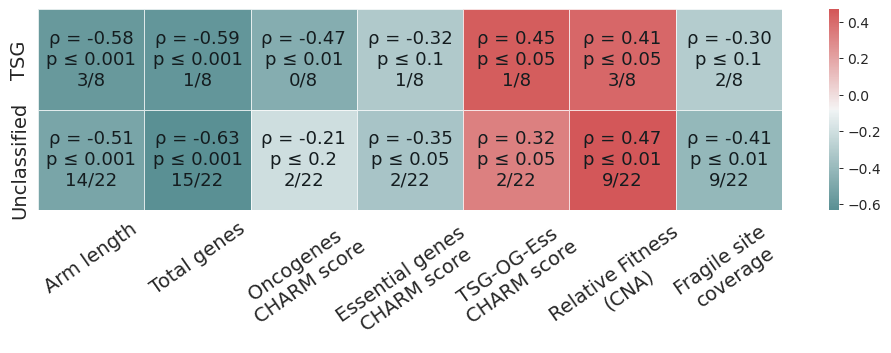

In [26]:
config_rcparams()

plt.figure(figsize=(12,2.6))
palette = sns.diverging_palette(200, 12, s=80, l=45, sep=1, center='light', as_cmap=True)
#palette = sns.cubehelix_palette(as_cmap=True, reverse=True, gamma=0.3,start=2)
ax = sns.heatmap(corrs, annot=annotations, fmt = "", linewidth=.5, cmap=palette,alpha=0.8, annot_kws={"fontsize": 13})
for text in ax.texts:
    text.set_color("#141C1F")

ax.set_yticklabels(labels = ['TSG','Unclassified'], rotation=0, fontsize=14)
ax.set_ylabel(None)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=90)

---